In [1]:
from datetime import datetime, timedelta, time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pm4py
import os

### Question 1: Initial Overview

In [2]:
# Load the event log used throughout Question 1
log = pm4py.read_xes("Event Logs/all.xes")
log.head(3)


/usr/local/lib/python3.12/dist-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/1820 [00:00<?, ?it/s]

,concept:name,time:timestamp,org:resource,lifecycle:transition,case:concept:name,case:customer_id,case:customer_name,case:customer_ssid,case:loan_amount,case:case_creation_no,...,loan_decision,loan_decision_extra,interest,loan_term_years,recipient,transfer_amount,repayments,installment_target,repaid_amount,cumulatively_repaid
0,Application Registered,2021-01-03 09:04:01+00:00,System Resource,complete,470-16,470,Customer 470,6c710e01-8262-41dd-8476-688b1513d23c,500.0,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Retrieve Identity Document,2021-01-03 09:04:02+00:00,System Resource,complete,470-16,470,Customer 470,6c710e01-8262-41dd-8476-688b1513d23c,500.0,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Retrieve Internal Log Data,2021-01-03 10:12:01+00:00,Risk Assessment System,complete,470-16,470,Customer 470,6c710e01-8262-41dd-8476-688b1513d23c,500.0,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**(a) Cases, events, unique activities, and timeframe**


In [3]:
n_cases      = log["case:concept:name"].nunique()
n_events     = len(log)
n_activities = log["concept:name"].nunique()
t_min, t_max = log["time:timestamp"].min(), log["time:timestamp"].max()
duration     = t_max - t_min

print(f"# cases             : {n_cases}")
print(f"# events            : {n_events}")
print(f"# unique activities : {n_activities}")
print(f"timeframe           : {t_min}  ->  {t_max}")
print(f"duration            : {duration}")


# cases             : 1820
# events            : 47553
# unique activities : 26
timeframe           : 2021-01-01 00:00:01+00:00  ->  2023-09-13 09:00:03+00:00
duration            : 985 days 09:00:02


**Answer (a):** The log contains **1 820 cases**, **47 553 events**, and **26 unique activities**.
It spans the period **2021-01-01 to 2023-09-13**, covering **985 days (≈2 years 8 months)**.


**(b) Number of variants and average events per case**


In [4]:
variants    = pm4py.get_variants(log)
n_variants  = len(variants)
avg_events  = log.groupby("case:concept:name").size().mean()

print(f"# variants           : {n_variants}")
print(f"avg events per case  : {avg_events:.2f}")


# variants           : 678
avg events per case  : 26.13


**Answer (b):** The log contains **678 distinct variants**.
On average a case consists of **≈26.13 events**.


**(c) Event attributes vs. case attributes, and event-attribute -> activity mapping**


In [5]:
case_cols  = [c for c in log.columns if c.startswith("case:")]
event_cols = [c for c in log.columns if not c.startswith("case:")]

print("Case attributes:")
for c in case_cols:
    print("  -", c)

print("\nEvent attributes:")
for c in event_cols:
    print("  -", c)

# Domain-specific event attributes (i.e. excluding the standard XES ones) and
# the activities at which they actually carry a value.
standard = {"concept:name", "time:timestamp", "org:resource", "lifecycle:transition"}
domain_attrs = [c for c in event_cols if c not in standard]

print("\nEvent attribute -> activities at which it is recorded:")
for col in domain_attrs:
    acts = sorted(log.loc[log[col].notna(), "concept:name"].unique())
    print(f"  {col:32s} -> {acts}")


Case attributes:
  - case:concept:name
  - case:customer_id
  - case:customer_name
  - case:customer_ssid
  - case:loan_amount
  - case:case_creation_no

Event attributes:
  - concept:name
  - time:timestamp
  - org:resource
  - lifecycle:transition
  - prior_defaults
  - prior_applications
  - auto_id_verification_outcome
  - risk_score
  - credit_score
  - code
  - manual_id_verification_outcome
  - loan_decision
  - loan_decision_extra
  - interest
  - loan_term_years
  - recipient
  - transfer_amount
  - repayments
  - installment_target
  - repaid_amount
  - cumulatively_repaid

Event attribute -> activities at which it is recorded:
  prior_defaults                   -> ['Create Assessment Report', 'Retrieve Internal Log Data']
  prior_applications               -> ['Create Assessment Report', 'Retrieve Internal Log Data']
  auto_id_verification_outcome     -> ['Verify ID Automatically']
  risk_score                       -> ['Create Assessment Report', 'Retrieve Customer Global R

**Answer (c):**

*Case attributes* (constant per case):
`case:concept:name`, `case:customer_id`, `case:customer_name`, `case:customer_ssid`,
`case:loan_amount`, `case:case_creation_no`.

*Event attributes* fall into two groups.
**Standard XES attributes** (recorded for every event):
`concept:name`, `time:timestamp`, `org:resource`, `lifecycle:transition`.
**Domain-specific event attributes** are produced only by the activity that creates them:

| Event attribute | Recorded by activity / activities |
|---|---|
| `auto_id_verification_outcome` | Verify ID Automatically |
| `manual_id_verification_outcome` | Verify ID Manually |
| `risk_score` | Retrieve Customer Global Risk Score, Create Assessment Report |
| `credit_score` | Retrieve Financial Status, Create Assessment Report |
| `prior_defaults` | Retrieve Internal Log Data, Create Assessment Report |
| `prior_applications` | Retrieve Internal Log Data, Create Assessment Report |
| `code` | Reject Application |
| `loan_decision` | Decide Loan Application |
| `loan_decision_extra` | Decide Loan Application |
| `interest` | Received Terms Acceptance |
| `loan_term_years` | Received Terms Acceptance |
| `recipient` | Transfer Funds |
| `transfer_amount` | Transfer Funds |
| `repayments` | Start Repayments |
| `installment_target` | Start Repayments |
| `repaid_amount` | Installment Received |
| `cumulatively_repaid` | Installment Received |

*Create Assessment Report* aggregates information collected by the three preceding "Retrieve ..."
activities, which is why it shows up as a second producer for several attributes.


**(d) Frequency distribution of variants**


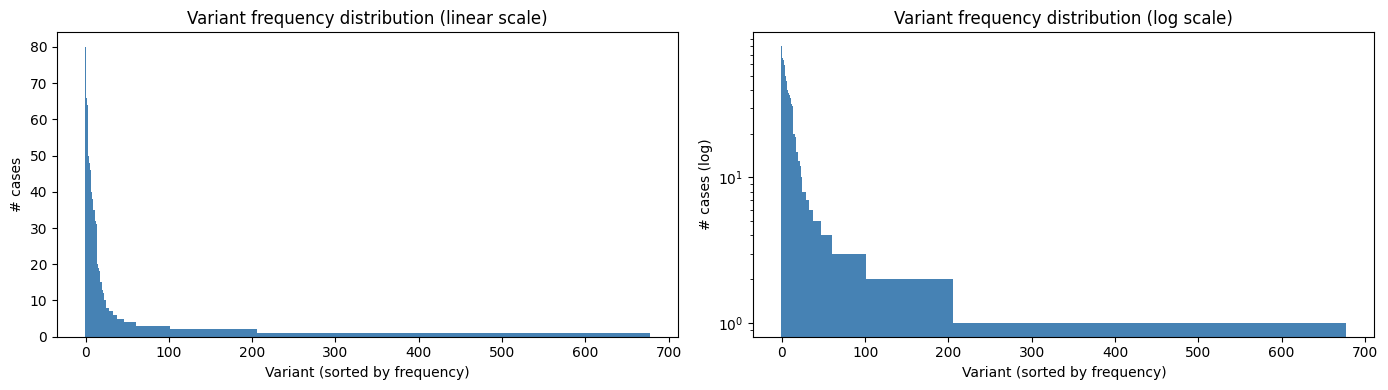

top-1 variant covers   : 80 cases (4.4%)
top-5 variants cover   : 319 cases (17.5%)
top-10 variants cover  : 528 cases (29.0%)
singleton variants     : 472 of 678 (69.6%)


In [6]:
freqs = sorted(pm4py.get_variants(log).values(), reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(len(freqs)), freqs, color="steelblue", width=1.0)
axes[0].set_xlabel("Variant (sorted by frequency)")
axes[0].set_ylabel("# cases")
axes[0].set_title("Variant frequency distribution (linear scale)")

axes[1].bar(range(len(freqs)), freqs, color="steelblue", width=1.0)
axes[1].set_yscale("log")
axes[1].set_xlabel("Variant (sorted by frequency)")
axes[1].set_ylabel("# cases (log)")
axes[1].set_title("Variant frequency distribution (log scale)")
plt.tight_layout(); plt.show()

n_singleton = sum(f == 1 for f in freqs)
print(f"top-1 variant covers   : {freqs[0]} cases ({100*freqs[0]/sum(freqs):.1f}%)")
print(f"top-5 variants cover   : {sum(freqs[:5])} cases ({100*sum(freqs[:5])/sum(freqs):.1f}%)")
print(f"top-10 variants cover  : {sum(freqs[:10])} cases ({100*sum(freqs[:10])/sum(freqs):.1f}%)")
print(f"singleton variants     : {n_singleton} of {len(freqs)} ({100*n_singleton/len(freqs):.1f}%)")


**Answer (d):** The distribution is **strongly long-tailed**: the most frequent variant occurs only 80 times (≈4.4 % of cases), the top-10 variants jointly account for only ≈29 % of cases, and ≈70 % of all variants (472 of 678) appear in a single case. The process therefore has no dominant happy path and exhibits a high degree of behavioural variability, which we should expect any subsequent process-discovery algorithm to struggle with.


**(e) Distribution of case durations**


min    : 0 days 06:06:02
max    : 758 days 10:28:02
mean   : 292 days 01:14:30.405494504
median : 220 days 20:38:04
std    : 220 days 18:18:33.765425954


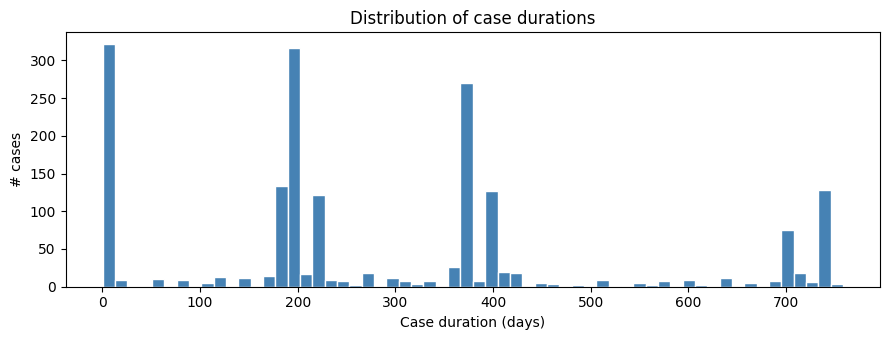

In [7]:
durations = (log.groupby("case:concept:name")["time:timestamp"]
                  .agg(lambda s: s.max() - s.min()))
secs = durations.dt.total_seconds()

print(f"min    : {durations.min()}")
print(f"max    : {durations.max()}")
print(f"mean   : {pd.to_timedelta(secs.mean(), unit='s')}")
print(f"median : {durations.median()}")
print(f"std    : {pd.to_timedelta(secs.std(),  unit='s')}")

plt.figure(figsize=(9, 3.5))
plt.hist(secs / 86400, bins=60, color="steelblue", edgecolor="white")
plt.xlabel("Case duration (days)")
plt.ylabel("# cases")
plt.title("Distribution of case durations")
plt.tight_layout(); plt.show()


**Answer (e):** Case durations range from **≈6 hours** to **≈758 days**, with a **mean of ≈292 days**, a **median of ≈221 days**, and a **standard deviation of ≈221 days**. The mean clearly exceeds the median and the standard deviation is of the same order of magnitude as the mean, so the distribution is **right-skewed and highly heterogeneous**. The histogram is in fact **multi-modal**, with four distinct clusters: very short cases (≈0 days, plausibly rejected applications that terminate right after the credit check) plus three pronounced peaks around **≈½, ≈1, and ≈2 years** – matching exactly the three observed `loan_term_years` values (0.5, 1.0, 2.0). The log therefore mixes structurally different sub-processes (rejection vs. accepted-and-repaid, and within the latter, three contractual term lengths), which already motivates the use-case-specific analyses in Question 3.


### Question 2: General Visual Analytics & Exploration

**(a) Variant Analysis – select 5 variants and report their frequencies**


In [8]:
# Five structurally different variants are deliberately picked to expose the
# main behavioural classes present in the log:
#   V1: most frequent overall - accepted, short loan, 6 installments
#   V2: accepted, longer loan, 12 installments
#   V3: rejected AFTER manual Decide Loan Application
#   V4: rejected BEFORE manual decision (auto-rejection)
#   V5: defaulted loan ending in Send to Collections

variants = pm4py.get_variants(log)

def find(target_freq, target_len, target_last, decide_required=None,
         contains=None):
    for v, c in variants.items():
        if c != target_freq or len(v) != target_len or v[-1] != target_last:
            continue
        if decide_required is True  and "Decide Loan Application" not in v: continue
        if decide_required is False and "Decide Loan Application" in v:     continue
        if contains and not all(a in v for a in contains):                  continue
        return v
    return None

selected = {
    "V1 (happy path, 6 installments)" : find(80, 23, "Repayment Completed"),
    "V2 (happy path, 12 installments)": find(50, 29, "Repayment Completed"),
    "V3 (rejected AFTER Decide)"     : find(38, 13, "Send Rejection Notification",
                                            decide_required=True),
    "V4 (rejected BEFORE Decide)"    : find(20, 11, "Send Rejection Notification",
                                            decide_required=False),
    "V5 (default - Send to Coll.)"   : find(3,  19, "Send to Collections"),
}

print(f"# variants in log: {len(variants)}\n")
for label, v in selected.items():
    print(f"{label}:  freq = {variants[v]:3d},  length = {len(v):2d}")


# variants in log: 678

V1 (happy path, 6 installments):  freq =  80,  length = 23
V2 (happy path, 12 installments):  freq =  50,  length = 29
V3 (rejected AFTER Decide):  freq =  38,  length = 13
V4 (rejected BEFORE Decide):  freq =  20,  length = 11
V5 (default - Send to Coll.):  freq =   3,  length = 19


In [9]:
# Print the activity sequences of the five selected variants
for label, v in selected.items():
    print(f"\n=== {label}  (freq={variants[v]}, length={len(v)}) ===")
    for i, a in enumerate(v, 1):
        print(f"  {i:2d}. {a}")



=== V1 (happy path, 6 installments)  (freq=80, length=23) ===
   1. Application Registered
   2. Retrieve Identity Document
   3. Retrieve Internal Log Data
   4. Verify ID Automatically
   5. Confirmed Identity
   6. Query Central Bank System
   7. Query Credit Bureau
   8. Retrieve Customer Global Risk Score
   9. Retrieve Financial Status
  10. Create Assessment Report
  11. Decide Loan Application
  12. Send Acceptance Confirmation
  13. Accept Terms
  14. Received Terms Acceptance
  15. Transfer Funds
  16. Start Repayments
  17. Installment Received
  18. Installment Received
  19. Installment Received
  20. Installment Received
  21. Installment Received
  22. Installment Received
  23. Repayment Completed

=== V2 (happy path, 12 installments)  (freq=50, length=29) ===
   1. Application Registered
   2. Retrieve Identity Document
   3. Retrieve Internal Log Data
   4. Verify ID Automatically
   5. Confirmed Identity
   6. Query Central Bank System
   7. Retrieve Customer Global

**Annotated visualization of variant V1 (the happy path)**


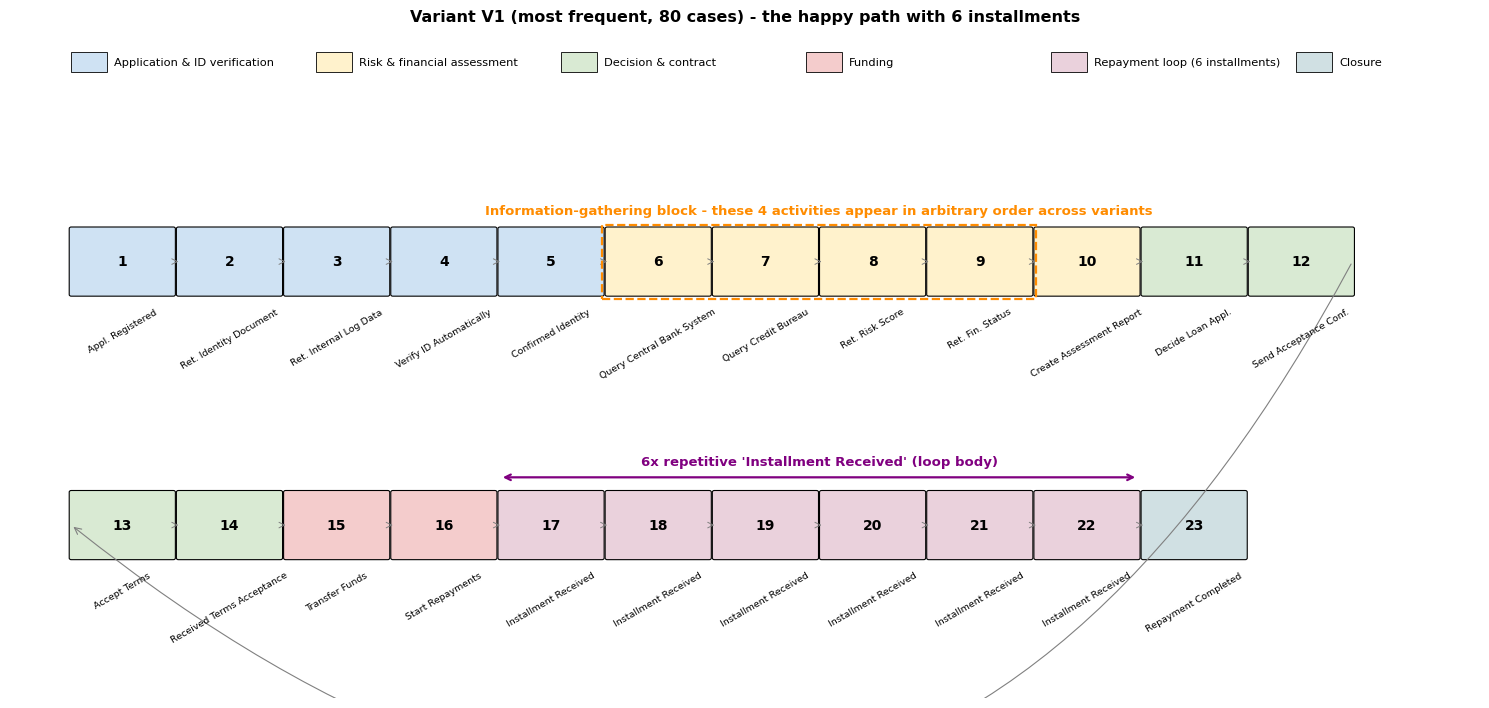

In [10]:
# Annotated visualization of V1 - we highlight the two patterns that recur
# across many other variants of the log:
#   * the 4-activity 'information-gathering block', whose internal order is
#     interchangeable across variants (compare V1, V2, V3, V4)
#   * the repetitive 'Installment Received' loop body (whose length encodes
#     the loan term: 6 installments = 0.5y, 12 = 1y, 24 = 2y)

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle

variant_v1 = selected["V1 (happy path, 6 installments)"]

phases = [
    ("Application & ID verification",   range(0,5),   "#cfe2f3"),
    ("Risk & financial assessment",     range(5,10),  "#fff2cc"),
    ("Decision & contract",             range(10,14), "#d9ead3"),
    ("Funding",                         range(14,16), "#f4cccc"),
    ("Repayment loop (6 installments)",  range(16,22), "#ead1dc"),
    ("Closure",                         range(22,23), "#d0e0e3"),
]

fig, ax = plt.subplots(figsize=(15, 7.2))
ax.set_xlim(-0.2, 14.2); ax.set_ylim(-0.2, 8); ax.axis("off")

box_w, box_h, per_row = 1.0, 0.8, 12
y_top, y_bot = 4.7, 1.5
positions = [(0.4 + (i % per_row)*1.05, y_top if i < per_row else y_bot)
             for i in range(len(variant_v1))]
color_of = {i: c for label, idx_range, c in phases for i in idx_range}

for i, (x, y) in enumerate(positions):
    ax.add_patch(FancyBboxPatch((x, y), box_w, box_h, boxstyle="round,pad=0.02",
                                 linewidth=0.8, facecolor=color_of[i],
                                 edgecolor="black"))
    ax.text(x + box_w/2, y + box_h/2, str(i+1),
            ha="center", va="center", fontsize=10, weight="bold")
    short = (variant_v1[i].replace("Retrieve ", "Ret. ")
                          .replace("Application", "Appl.")
                          .replace("Confirmation", "Conf.")
                          .replace("Customer Global ", "")
                          .replace("Financial Status", "Fin. Status"))
    ax.text(x + box_w/2, y - 0.15, short,
            ha="center", va="top", fontsize=6.8, rotation=30)

# horizontal arrows within rows
for i in range(len(variant_v1) - 1):
    if i == per_row - 1:
        continue
    (x1, y1), (x2, y2) = positions[i], positions[i+1]
    ax.add_patch(FancyArrowPatch((x1+box_w, y1+box_h/2), (x2, y2+box_h/2),
                  arrowstyle="->", mutation_scale=10, color="grey", lw=0.7))

# row-wrap arrow
(x1, y1) = positions[per_row-1]; (x2, y2) = positions[per_row]
ax.add_patch(FancyArrowPatch((x1+box_w, y1+box_h/2), (x2, y2+box_h/2),
              arrowstyle="->", mutation_scale=12, color="grey", lw=0.8,
              connectionstyle="arc3,rad=-0.6"))

# annotation: 6x repetitive installment loop
inst_idx = list(range(16, 22))
xs = [positions[i][0] for i in inst_idx]
y_lab = positions[inst_idx[0]][1] + box_h + 0.18
ax.annotate("", xy=(xs[-1] + box_w, y_lab), xytext=(xs[0], y_lab),
            arrowprops=dict(arrowstyle="<->", color="purple", lw=1.6))
ax.text((xs[0] + xs[-1] + box_w)/2, y_lab + 0.15,
        "6x repetitive 'Installment Received' (loop body)",
        ha="center", color="purple", fontsize=9.5, weight="bold")

# annotation: information-gathering block
info_idx = list(range(5, 9))
xs2 = [positions[i][0] for i in info_idx]
y_box_top = positions[info_idx[0]][1] + box_h
ax.add_patch(Rectangle((xs2[0]-0.05, positions[info_idx[0]][1]-0.05),
                        xs2[-1]+box_w-xs2[0]+0.1, box_h+0.10,
                        fill=False, edgecolor="darkorange", lw=1.6, ls="--"))
ax.text((xs2[0] + xs2[-1] + box_w)/2, y_box_top + 0.18,
        "Information-gathering block - these 4 activities appear in arbitrary order across variants",
        ha="center", color="darkorange", fontsize=9.5, weight="bold")

# legend
y_leg = 7.4
for k, (label, _, col) in enumerate(phases):
    x_l = 0.4 + k * 2.4
    ax.add_patch(Rectangle((x_l, y_leg), 0.35, 0.25,
                  facecolor=col, edgecolor="black", lw=0.6))
    ax.text(x_l + 0.42, y_leg + 0.12, label, va="center", fontsize=8.2)

ax.set_title("Variant V1 (most frequent, 80 cases) - the happy path with 6 installments",
             fontsize=11.5, weight="bold", y=0.99)
plt.tight_layout(); plt.show()


**Comparison of the 5 selected variants (activities, length, attributes)**


In [11]:
# Build a comparison table along: contained activities, length, and
# the domain-specific attributes that are populated in an example case
# of each variant.

attr_cols = ['risk_score','credit_score','code','loan_decision',
             'auto_id_verification_outcome','manual_id_verification_outcome',
             'transfer_amount','interest','loan_term_years','repaid_amount']

case_act_seq = (log.sort_values("time:timestamp")
                   .groupby("case:concept:name")["concept:name"]
                   .apply(tuple))

rows = []
for label, v in selected.items():
    cases = case_act_seq[case_act_seq == v].index.tolist()
    cid   = cases[0]
    sub   = log[log["case:concept:name"] == cid]
    dur   = sub["time:timestamp"].max() - sub["time:timestamp"].min()
    populated = {col: sub.loc[sub[col].notna(), col].astype(str).unique().tolist()
                 for col in attr_cols if sub[col].notna().any()}
    rows.append({
        "variant": label,
        "freq":    variants[v],
        "length":  len(v),
        "# distinct activities": len(set(v)),
        "example case":         cid,
        "example duration":     str(dur),
        "populated attributes": populated,
    })

cmp_df = pd.DataFrame(rows)
print(cmp_df[["variant","freq","length","# distinct activities",
              "example case","example duration"]].to_string(index=False))

print("\nPopulated domain-specific attributes (one example case per variant):")
for r in rows:
    print(f"\n{r['variant']}  (case {r['example case']}):")
    for k, vals in r["populated attributes"].items():
        print(f"   {k:32s} -> {vals}")


                         variant  freq  length  # distinct activities example case  example duration
 V1 (happy path, 6 installments)    80      23                     18     101-1919 189 days 16:29:08
V2 (happy path, 12 installments)    50      29                     18      101-465 372 days 08:42:05
      V3 (rejected AFTER Decide)    38      13                     13     147-1907   0 days 17:05:02
     V4 (rejected BEFORE Decide)    20      11                     11     195-1320   0 days 23:05:01
    V5 (default - Send to Coll.)     3      19                     19     320-1337  24 days 08:20:05

Populated domain-specific attributes (one example case per variant):

V1 (happy path, 6 installments)  (case 101-1919):
   risk_score                       -> ['0.17']
   credit_score                     -> ['828.37']
   loan_decision                    -> ['accept']
   auto_id_verification_outcome     -> ['valid']
   transfer_amount                  -> ['500.0']
   interest                

**Answer (a):** The five variants have very different lengths (11–29 events) but reuse the same building blocks:

* **Contained activities.** All five start with the same five-activity application/ID-verification block, then perform the same four-activity information-gathering block. They differ in what comes *after* the assessment: V1/V2 enter the contract → funding → repayment branch and end with `Repayment Completed`; V3 follows the manual rejection branch (`Decide Loan Application` → `Reject Application` → `Send Rejection Notification`); V4 is auto-rejected and *skips* `Decide Loan Application` entirely; V5 is initially accepted but defaults and ends with the collections branch (`Loan Default Notice Received` → `Formally Initiate Debt Recovery` → `Send to Collections`).
* **Length.** The length is dominated by the number of `Installment Received` events, which equals 6, 12, and ≈3–4 in V1, V2, V5 respectively, and is zero in the rejection variants V3/V4.
* **Attributes.** V1/V2 carry the full accepted-loan attribute set (`loan_decision = accept`, `interest`, `loan_term_years`, `transfer_amount`, `repaid_amount`); V3 carries `loan_decision = reject` plus a rejection `code` (here MLA); V4 carries only the rejection `code` (here LCS) but **no** `loan_decision` (because `Decide Loan Application` was skipped); V5 carries the same attributes as V1/V2 but no full `Repayment Completed`. The two rejection variants differ in their `risk_score` (0.32 vs. 0.69), confirming that very high risk leads to auto-rejection without manual decision. We also notice that V1 (case `101-1919`) and V2 (case `101-465`) belong to the **same customer** (`101`) – customers can therefore have several loans over time.


**(b) Frequency-annotated Directly-Follows Graph (DFG)**


# DFG edges       : 81
# start activities: 1 -> {'Application Registered': 1820}
# end activities  : 3   -> {'Send Rejection Notification': 321, 'Send to Collections': 318, 'Repayment Completed': 1181}

Top 10 directly-follows relations:
  13990   Installment Received  ->  Installment Received
   1820   Application Registered  ->  Retrieve Identity Document
   1671   Create Assessment Report  ->  Decide Loan Application
   1499   Accept Terms  ->  Received Terms Acceptance
   1499   Decide Loan Application  ->  Send Acceptance Confirmation
   1499   Received Terms Acceptance  ->  Transfer Funds
   1499   Send Acceptance Confirmation  ->  Accept Terms
   1499   Transfer Funds  ->  Start Repayments
   1468   Verify ID Automatically  ->  Confirmed Identity
   1419   Start Repayments  ->  Installment Received


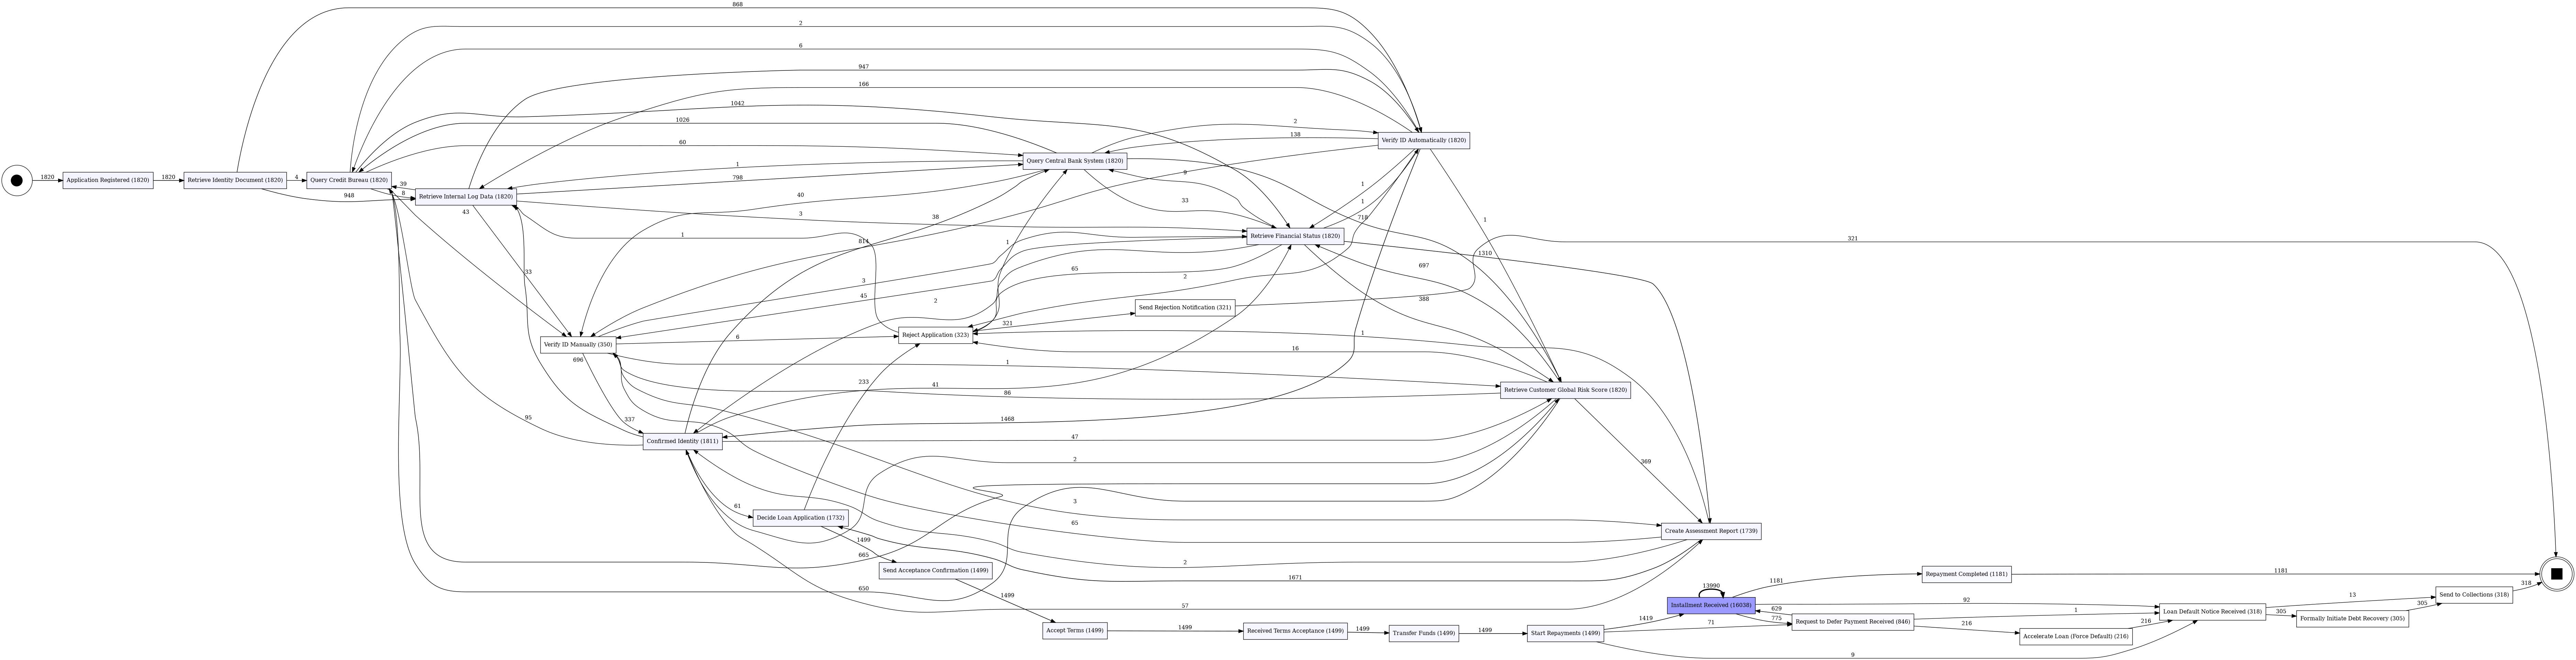

In [12]:
dfg, start_acts, end_acts = pm4py.discover_directly_follows_graph(log)

print(f"# DFG edges       : {len(dfg)}")
print(f"# start activities: {len(start_acts)} -> {dict(start_acts)}")
print(f"# end activities  : {len(end_acts)}   -> {dict(end_acts)}")
print(f"\nTop 10 directly-follows relations:")
for (a, b), c in sorted(dfg.items(), key=lambda kv: -kv[1])[:10]:
    print(f"  {c:5d}   {a}  ->  {b}")

# Render the DFG inline in the notebook
from IPython.display import Image
pm4py.save_vis_dfg(dfg, start_acts, end_acts, "dfg_all.png")
Image("dfg_all.png")


**Answer (b):** The DFG has a **single start** (`Application Registered`, all 1 820 cases) and **three end activities** corresponding to the three possible case outcomes: `Repayment Completed` (1 181), `Send Rejection Notification` (321) and `Send to Collections` (318) – which together prove that ≈65 % of loans are successfully repaid, ≈18 % are rejected up front and ≈17 % default after acceptance. The strongest edge by far is the **`Installment Received` self-loop with 13 990 occurrences** (≈30 % of all events), followed by the rigid sequence around `Decide Loan Application → Send Acceptance Confirmation → Accept Terms → Received Terms Acceptance → Transfer Funds → Start Repayments` (≈1 499 occurrences each), which is the deterministic "contract & funding" backbone. In contrast, the four information-gathering activities (`Query Central Bank System`, `Query Credit Bureau`, `Retrieve Customer Global Risk Score`, `Retrieve Financial Status`) form a densely interconnected sub-graph with edges in many directions – a clear DFG signature of **concurrent / parallel execution**, which matches the observation in (a) that their order varies across variants and is the main reason behind the long-tailed variant distribution from Question 1(d). Finally, the edge `Verify ID Automatically → Verify ID Manually` reveals an exception path: when automatic ID verification fails, a manual fallback is invoked – this explains a large share of the 243 variants that contain `Verify ID Manually`.


### Question 3: Use Case-Specific Visual Analytics & Exploration

### Question 4: Process Discovery

### Question 5: Conformance Checking

**(a) Load and visualize the two Petri nets**


In [13]:
# Load both Petri nets
pn_ind,  im_ind,  fm_ind  = pm4py.read_pnml("Input Process Models/pn-loan-inductive.pnml")
pn_hand, im_hand, fm_hand = pm4py.read_pnml("Input Process Models/pn-loan-handmade.pnml")

def describe(name, pn):
    visible = [t for t in pn.transitions if t.label is not None]
    silent  = [t for t in pn.transitions if t.label is None]
    from collections import Counter
    dup = {l:c for l,c in Counter(t.label for t in visible).items() if c > 1}
    print(f"{name:25s}  places={len(pn.places):3d}  transitions={len(pn.transitions):3d}"
          f"  (visible={len(visible)}, silent={len(silent)})  arcs={len(pn.arcs):3d}")
    if dup:
        print(f"   duplicate labels: {dup}")

describe("pn_loan_inductive", pn_ind)
describe("pn_loan_handmade",  pn_hand)


pn_loan_inductive          places= 36  transitions= 39  (visible=26, silent=13)  arcs= 90
pn_loan_handmade           places= 27  transitions= 32  (visible=29, silent=3)  arcs= 69
   duplicate labels: {'Reject Application': 3, 'Confirmed Identity': 2}


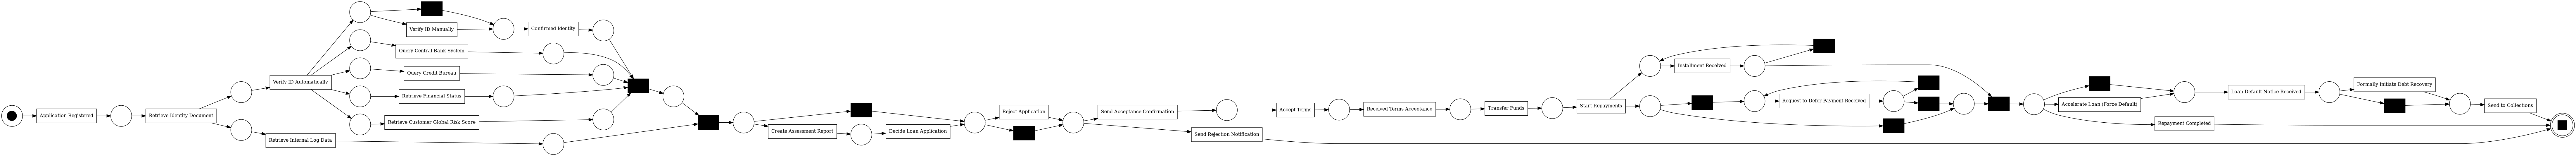

In [14]:
# Visualize the inductive Petri net (rendered inline)
from IPython.display import Image
pm4py.save_vis_petri_net(pn_ind, im_ind, fm_ind, "pn_inductive.png")
Image("pn_inductive.png")


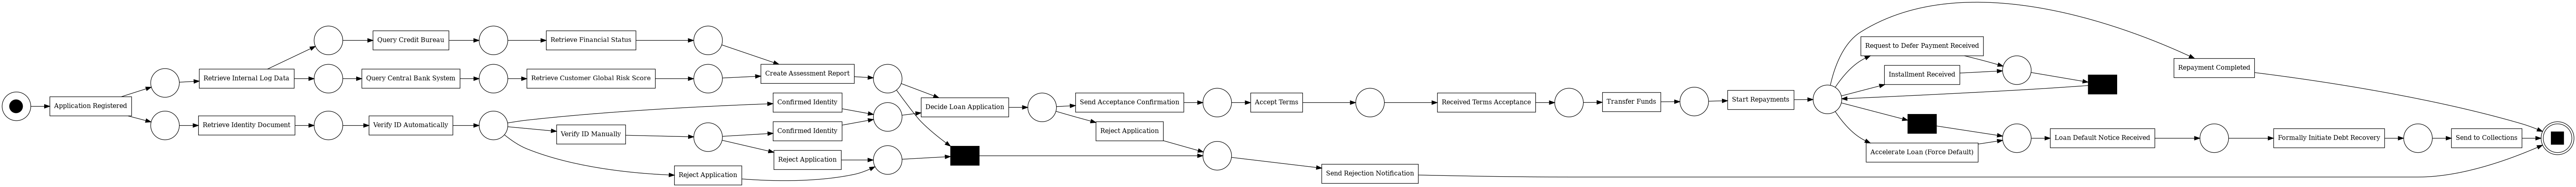

In [15]:
# Visualize the handmade Petri net (rendered inline)
pm4py.save_vis_petri_net(pn_hand, im_hand, fm_hand, "pn_handmade.png")
Image("pn_handmade.png")


**Answer (a):** Both nets work over the **same 26 activity labels** but differ structurally. The **inductive** model has 36 places, 39 transitions (26 visible + 13 silent) and 90 arcs; every label is unique and the many τ-transitions encode skips/loops in the typical Inductive-Miner block-structured layout, which makes the net larger but each part of the behaviour explicit. The **handmade** model is more compact – 27 places, 32 transitions (29 visible + only 3 silent) and 69 arcs – and deliberately uses **duplicate labels**: `Reject Application` appears **3 times** (the three rejection points: auto-reject before manual decision, reject inside the manual decision, and reject after `Decide Loan Application`) and `Confirmed Identity` appears **twice** (after the automatic and after the manual ID-verification path). The handmade model therefore encodes domain semantics directly via duplication, whereas the inductive model produces a single transition per label and embeds the same meaning structurally through silent routing places.


**(b) Token-based fitness, alignment-based fitness and alignment-based precision on `all.xes`**


In [16]:
def evaluate(name, pn, im, fm):
    tb_fit  = pm4py.fitness_token_based_replay(log, pn, im, fm)
    al_fit  = pm4py.fitness_alignments(log,    pn, im, fm)
    al_prec = pm4py.precision_alignments(log,  pn, im, fm)
    print(f"\n=== {name} ===")
    print(f"  token-based fitness     : log_fitness  = {tb_fit['log_fitness']:.4f},"
          f"  perc_fit_traces = {tb_fit['perc_fit_traces']:.2f}%")
    print(f"  alignment-based fitness : log_fitness  = {al_fit['log_fitness']:.4f},"
          f"  perc_fit_traces = {al_fit['percentage_of_fitting_traces']:.2f}%")
    print(f"  alignment-based precision: {al_prec:.4f}")
    return {"tb": tb_fit['log_fitness'], "al": al_fit['log_fitness'],
            "fit_traces": al_fit['percentage_of_fitting_traces'], "prec": al_prec}

scores_ind  = evaluate("pn_loan_inductive", pn_ind,  im_ind,  fm_ind)
scores_hand = evaluate("pn_loan_handmade",  pn_hand, im_hand, fm_hand)


replaying log with TBR, completed traces ::   0%|          | 0/678 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/678 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/4984 [00:00<?, ?it/s]


=== pn_loan_inductive ===
  token-based fitness     : log_fitness  = 0.9967,  perc_fit_traces = 95.22%
  alignment-based fitness : log_fitness  = 0.9974,  perc_fit_traces = 95.22%
  alignment-based precision: 0.7311


replaying log with TBR, completed traces ::   0%|          | 0/678 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/678 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/4984 [00:00<?, ?it/s]


=== pn_loan_handmade ===
  token-based fitness     : log_fitness  = 0.9974,  perc_fit_traces = 94.29%
  alignment-based fitness : log_fitness  = 0.9971,  perc_fit_traces = 94.29%
  alignment-based precision: 0.5827


**Answer (b):** Both models replay `all.xes` very well in terms of fitness, but differ markedly in precision.

| Metric | `pn_loan_inductive` | `pn_loan_handmade` |
|---|---|---|
| Token-based fitness (`log_fitness`) | **0.9967** | **0.9974** |
| Alignment-based fitness (`log_fitness`) | **0.9974** | **0.9971** |
| % perfectly fitting traces | **95.22 %** | **94.29 %** |
| Alignment-based precision | **0.7311** | **0.5827** |


**(c) Soundness of `pn_loan_handmade`**


In [17]:
# Run the Woflan-based soundness check on the handmade net
sound_ok, diag = pm4py.check_soundness(pn_hand, im_hand, fm_hand)
print(f"is_sound = {sound_ok}")
print("Diagnostic messages:")
from pm4py.algo.analysis.woflan.algorithm import Outputs
for m in diag[Outputs.DIAGNOSTIC_MESSAGES]:
    print(" -", m)


is_sound = True
Diagnostic messages:
 - Input is ok.
 - Petri Net is a workflow net.
 - Every place is covered by s-components.
 - There are no dead tasks.
 - All tasks are live.


/tmp/ipykernel_535/1982517082.py:2: DeprecatedWarning: check_soundness is deprecated as of 2.3.0 and will be removed in 3.0.0. this method will be removed in a future release.
  sound_ok, diag = pm4py.check_soundness(pn_hand, im_hand, fm_hand)
/usr/local/lib/python3.12/dist-packages/pm4py/algo/analysis/woflan/place_invariants/utility.py:163: UserWarning: solution from scipy may be unstable. Please install PuLP (pip install pulp) for fully reliable results.
  warnings.warn(


**Answer (c):** `pm4py.check_soundness` returns `True` for `pn_loan_handmade`, so all four properties of (Workflow-net) soundness hold. Concretely, the diagnostic messages confirm:

| Property | Holds? | Evidence from `check_soundness` / Woflan |
|---|---|---|
| **Workflow-net structure** (single source place, single sink place, every node on a path source → sink) | ✓ | *"Petri Net is a workflow net."* |
| **Option to complete** (from every reachable marking the final marking `[n25]` is reachable) | ✓ | *"Every place is covered by s-components."* (the s-component cover guarantees that no token can be "lost" – every marking can still progress to the final marking) |
| **Proper completion** (when the final marking is reached, no other token is left anywhere) | ✓ | The same s-component cover, together with the workflow-net structure, certifies that the marking `[n25]` is the only "dead" marking and that it contains exactly one token. |
| **No dead transitions** (every transition can fire in some run from `[n17]`) | ✓ | *"There are no dead tasks."* and *"All tasks are live."* |

The duplicate `Reject Application` and `Confirmed Identity` transitions therefore do not break soundness – each of them remains reachable and live in the Woflan-constructed reachability graph.


**(d) Which model better represents the actual process?**


**Answer (d):** Although the two models are very close on fitness (~0.997 each), the **`pn_loan_inductive` model better represents the *actual* process** as observed in `all.xes`, for three concrete reasons.

* **Scores.** The inductive model has the higher alignment-based **precision (0.7311 vs. 0.5827)** and the higher share of **perfectly fitting traces (95.22 % vs. 94.29 %)**, while fitness is essentially tied. Higher precision means the inductive model permits substantially less behaviour that was *not* observed – which is what we want for a descriptive model.
* **Permitted behaviour.** The lower precision of the handmade model is a direct consequence of how it encodes rejections: by giving `Reject Application` three places of equal status it allows manual decision-rejections to skip the assessment-report step, and it also permits combinations of the auto-reject and the manual-decision-reject paths that never appear together in the data. Conversely, the handmade model does *not* allow some flows that we did observe in Q3 (auto-rejection of LCS cases without `Decide Loan Application`); we will quantify this in (e)–(h).
* **Complexity & process understanding.** The handmade net is in absolute terms slightly smaller (27 places / 32 transitions vs. 36 / 39) but uses 3 duplicate labels, which is harder for an analyst to read in a complex net than the inductive model's unique-labels-with-τ-routing layout. Combined with (a) and (c) above, this makes the inductive model the better choice for *describing* the actual process. The handmade model remains the right reference for the *normative* perspective – which is exactly the role it now takes for parts (e)–(i).


The process owner declares `pn_loan_handmade` to be the *normative* model. We now compute alignments of three sub-logs against this model and inspect the deviations:

* **(e)** `accepted-loans.xes` — cases that ended in an accepted, transferred loan
* **(g)** `lcs-rejected-customers.xes` — cases of customers ever rejected with the LCS code
* **(h)** `mid-rejected-customers.xes` — cases of customers ever rejected with the MID code

A re-usable helper function is defined first; (e) reuses it on the accepted-loans log, (g) and (h) repeat the analysis (= steps e and f) on their respective sub-logs.


**(e) Alignments on `accepted-loans.xes` — which activities appear problematic?**


In [18]:
from collections import Counter

def conformance_report(log_path, label, n_examples=2):
    sub_log = pm4py.read_xes(log_path)
    n_cases = sub_log["case:concept:name"].nunique()
    fit     = pm4py.fitness_alignments(sub_log, pn_hand, im_hand, fm_hand)
    aligns  = pm4py.conformance_diagnostics_alignments(sub_log, pn_hand, im_hand, fm_hand)

    log_moves   = Counter()  # event in log not allowed by model here
    model_moves = Counter()  # visible activity expected by model but missing in log
    bad         = []
    case_ids    = sub_log["case:concept:name"].unique()
    for cid, al in zip(case_ids, aligns):
        deviating = False
        for log_lbl, model_lbl in al["alignment"]:
            if log_lbl == ">>" and model_lbl is not None:        # visible model move
                model_moves[model_lbl] += 1
                deviating = True
            elif model_lbl == ">>":                              # log move
                log_moves[log_lbl] += 1
                deviating = True
        if deviating:
            bad.append((cid, al["fitness"]))

    print(f"\n############ {label} ############")
    print(f"  # cases               : {n_cases}")
    print(f"  alignment log fitness : {fit['log_fitness']:.4f}")
    print(f"  % perfectly fitting   : {fit['percentage_of_fitting_traces']:.2f}%")
    print(f"  # non-fitting traces  : {len(bad)}")
    print("  Top model moves (activities expected by model, missing in log):")
    for a, c in model_moves.most_common(5):
        print(f"     {c:5d}   {a}")
    print("  Top log moves (activities in log, not allowed by model here):")
    for a, c in log_moves.most_common(5):
        print(f"     {c:5d}   {a}")

    # show a couple of example alignments for non-fitting traces
    if bad:
        print(f"\n  Example alignments of non-fitting cases:")
        for cid, _ in bad[:n_examples]:
            ai = next(a for c, a in zip(case_ids, aligns) if c == cid)
            print(f"  --- case {cid}  (fitness {ai['fitness']:.3f}) ---")
            for log_lbl, model_lbl in ai["alignment"]:
                if log_lbl == ">>" and model_lbl is None:
                    continue   # silent model move - hide for readability
                marker = "ok" if (log_lbl != ">>" and model_lbl != ">>") else (
                          "M>" if log_lbl == ">>" else "L>")
                print(f"     {marker}  log={log_lbl!s:<40s}  model={model_lbl}")
    return {"fit": fit, "log_moves": log_moves, "model_moves": model_moves}

res_acc = conformance_report("Event Logs/accepted-loans.xes",
                              "(e) ACCEPTED-LOANS  vs  pn_loan_handmade")


parsing log, completed traces ::   0%|          | 0/1499 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/617 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/617 [00:00<?, ?it/s]


############ (e) ACCEPTED-LOANS  vs  pn_loan_handmade ############
  # cases               : 1499
  alignment log fitness : 0.9995
  % perfectly fitting   : 98.60%
  # non-fitting traces  : 21
  Top model moves (activities expected by model, missing in log):
        13   Formally Initiate Debt Recovery
         5   Query Credit Bureau
         2   Retrieve Internal Log Data
         1   Query Central Bank System
  Top log moves (activities in log, not allowed by model here):
         5   Query Credit Bureau
         2   Retrieve Internal Log Data
         1   Query Central Bank System

  Example alignments of non-fitting cases:
  --- case 635-446  (fitness 0.950) ---
     ok  log=Application Registered                    model=Application Registered
     ok  log=Retrieve Identity Document                model=Retrieve Identity Document
     M>  log=>>                                        model=Retrieve Internal Log Data
     ok  log=Query Credit Bureau                       model=Qu

**Answer (e):** Almost all accepted loans fit the normative model (alignment log-fitness ≈ **0.9995**, **98.60 %** of traces fit perfectly). Among the 21 deviating cases, the only systematically problematic activity is **`Formally Initiate Debt Recovery`** – it accounts for the large majority of the visible model moves, meaning the model expected that activity but the log did not record it. A handful of cases additionally show small ordering issues around `Retrieve Internal Log Data` / `Query Credit Bureau` / `Query Central Bank System`.


**(f) Manually inspect a few alignments on `accepted-loans.xes` — describe 2 reasons for conformance issues**


**Answer (f):** The two example alignments above point to two distinct conformance issues:

1. **Skipped formal debt-recovery step on default cases.** When an accepted loan eventually defaults, the normative model requires `Loan Default Notice Received → Formally Initiate Debt Recovery → Send to Collections`. In several cases the log jumps straight from `Loan Default Notice Received` to `Send to Collections` (model move on `Formally Initiate Debt Recovery`). The collections process is therefore initiated without the formal recovery being recorded as executed.
2. **Local re-ordering inside the information-gathering block.** `Retrieve Internal Log Data`, `Query Credit Bureau`, `Query Central Bank System` and `Retrieve Financial Status` form a parallel block whose model imposes a stricter ordering than the log realises (cf. the example case where `Query Credit Bureau` happens before `Retrieve Internal Log Data`, producing one log move + one model move for the same activity). This is a precision/concurrency mismatch rather than a substantive process violation.


**(g) Repeat steps (e) and (f) on `lcs-rejected-customers.xes`**


In [19]:
res_lcs = conformance_report("Event Logs/lcs-rejected-customers.xes",
                              "(g) LCS-REJECTED  vs  pn_loan_handmade")


parsing log, completed traces ::   0%|          | 0/139 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/58 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/58 [00:00<?, ?it/s]


############ (g) LCS-REJECTED  vs  pn_loan_handmade ############
  # cases               : 139
  alignment log fitness : 0.9533
  % perfectly fitting   : 41.01%
  # non-fitting traces  : 82
  Top model moves (activities expected by model, missing in log):
        81   Create Assessment Report
        79   Decide Loan Application
         1   Query Credit Bureau
  Top log moves (activities in log, not allowed by model here):
         2   Reject Application
         1   Query Credit Bureau

  Example alignments of non-fitting cases:
  --- case 756-74  (fitness 0.913) ---
     ok  log=Application Registered                    model=Application Registered
     ok  log=Retrieve Identity Document                model=Retrieve Identity Document
     ok  log=Verify ID Automatically                   model=Verify ID Automatically
     ok  log=Retrieve Internal Log Data                model=Retrieve Internal Log Data
     ok  log=Query Central Bank System                 model=Query Central Ban

**Answer (g):** The LCS sub-log conforms much worse than the accepted loans: alignment fitness drops to **0.9533** and only **41.0 %** of the 139 traces fit perfectly. The dominant deviation is structural: in 81 / 79 cases respectively, **`Create Assessment Report` and `Decide Loan Application` are expected by the model but never occur in the log**. Looking at the example alignments, this happens whenever a customer is **auto-rejected** because of a too-high risk score: the log goes directly `Retrieve Financial Status → Reject Application → Send Rejection Notification`, completely skipping the assessment report and the manual decision. The normative model does *not* foresee this short-cut – every rejection path in `pn_loan_handmade` flows through `Decide Loan Application`, which is exactly the deviation we already identified in Q3(c).

**Reasons for conformance issues here:**

1. **Auto-rejection bypasses the manual decision.** The hard-coded high-risk auto-rejection in the system is not represented in the normative model, producing the systematic *model moves* on `Create Assessment Report` and `Decide Loan Application`.
2. **`Reject Application` issued at an unexpected position.** A small number of cases (2) trigger `Reject Application` at a moment the normative model does not allow it, producing a *log move*. These are most likely cases where a previous application of the same customer was already rejected and the rejection event leaked into the next case (the LCS sub-log contains *all* cases of customers ever rejected with LCS, so multiple loan attempts of the same customer are present).


**(h) Repeat steps (e) and (f) on `mid-rejected-customers.xes`**


In [20]:
res_mid = conformance_report("Event Logs/mid-rejected-customers.xes",
                              "(h) MID-REJECTED  vs  pn_loan_handmade")


parsing log, completed traces ::   0%|          | 0/8 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/6 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/6 [00:00<?, ?it/s]


############ (h) MID-REJECTED  vs  pn_loan_handmade ############
  # cases               : 8
  alignment log fitness : 0.9780
  % perfectly fitting   : 75.00%
  # non-fitting traces  : 2
  Top model moves (activities expected by model, missing in log):
         2   Create Assessment Report
  Top log moves (activities in log, not allowed by model here):
         2   Reject Application

  Example alignments of non-fitting cases:
  --- case 358-964  (fitness 0.909) ---
     ok  log=Application Registered                    model=Application Registered
     ok  log=Retrieve Identity Document                model=Retrieve Identity Document
     ok  log=Retrieve Internal Log Data                model=Retrieve Internal Log Data
     ok  log=Verify ID Automatically                   model=Verify ID Automatically
     ok  log=Reject Application                        model=Reject Application
     ok  log=Query Central Bank System                 model=Query Central Bank System
     ok  log=Que

**Answer (h):** The MID sub-log is small (8 cases) and conforms well at the aggregate level (alignment fitness **0.978**, **75 %** perfectly fitting), but the two non-fitting cases reveal an interesting pattern: each contains **`Reject Application` *twice*** – once as a sync move and once as a log move – and skips `Create Assessment Report`.

**Reasons for conformance issues here:**

1. **Two rejections in the same case.** The customer's documents are first found to be missing/incorrect → `Reject Application` is issued *immediately* after `Verify ID Automatically`. The case continues with the standard information-gathering activities (perhaps because the customer resubmitted the documents) and is then rejected a *second* time. The normative model only allows a single `Reject Application` per case, so the second occurrence is reported as a log move.
2. **Skipped assessment for an obviously-deficient application.** When the application is rejected directly because of a MID issue, `Create Assessment Report` is not produced – the model expects it, hence the visible model move on `Create Assessment Report`. This is the same structural class of deviation we saw with LCS auto-rejections, just on a much smaller scale.


**(i) Summary of findings and recommendations**


**Answer (i):** The normative model fits the accepted-loans branch nearly perfectly (≥98.6 % fitting traces) but **systematically fails to capture the early-rejection short-cuts** that exist in reality – specifically the auto-rejection of high-risk customers (LCS) and the immediate rejection of applications with missing/incorrect documents (MID), in both of which `Create Assessment Report` and `Decide Loan Application` are skipped. Two improvements are therefore worth recommending: (i) **redesign the normative model** so that the rejection branch can also be entered *before* `Create Assessment Report` and *without* `Decide Loan Application`, reflecting the real auto-rejection logic, and ensure that `Formally Initiate Debt Recovery` is enforced (not skipped) on every default-to-collections path; and (ii) **harmonise rejection handling at the IT level** so that a single application is rejected at most once (the duplicated `Reject Application` events seen in MID cases either indicate a bug in the case-id assignment or, more likely, a process gap where a re-submission re-uses the same case rather than opening a new one).
